In [10]:
import pandas as pd
import seaborn as sns
import matplotlib
matplotlib.use("Agg") 
%matplotlib inline
import matplotlib.pyplot as plt
import argparse  
import sqlite3
from threading import Thread

cnx = sqlite3.connect('./data_copy.db')
try:
    cnx.execute('''
            CREATE INDEX IF NOT EXISTS idx_elasticity_lookup 
            ON data (experiment, provider, date_time, language, cpu, memory, timestamp)
    ''')
    cnx.commit()
    print("Index created/verified")
except Exception as e:
    print(f"Index creation note: {e}")

Index created/verified


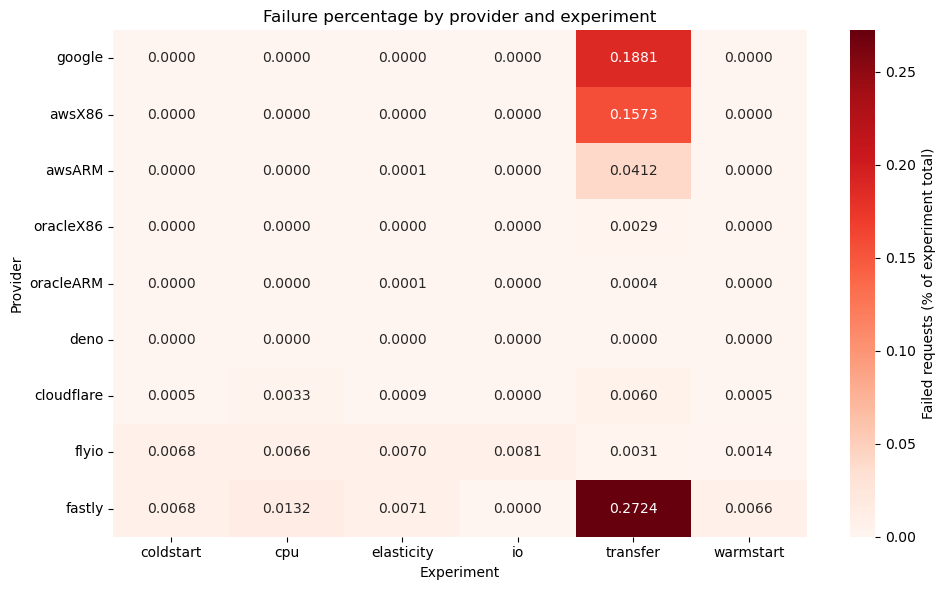

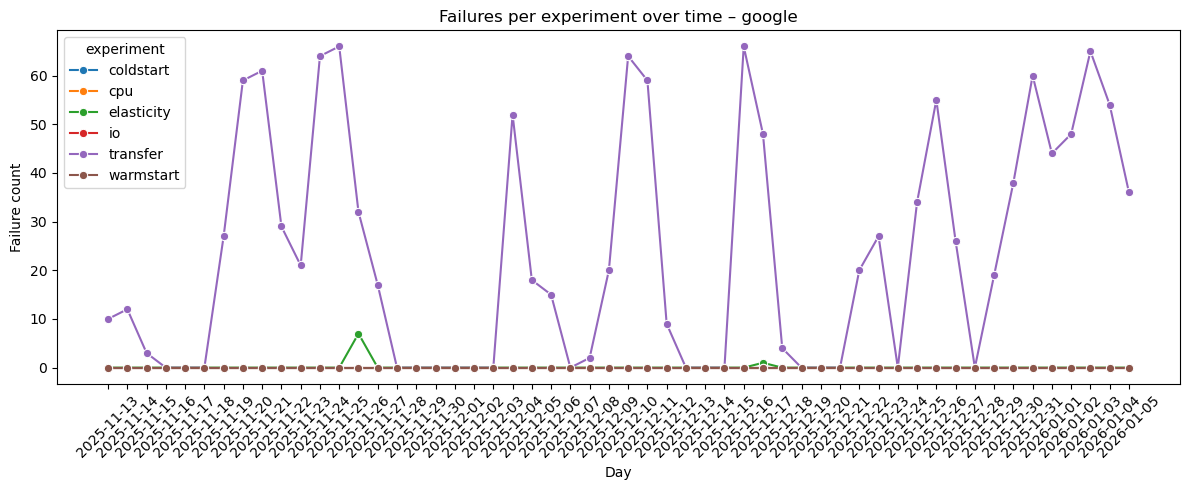

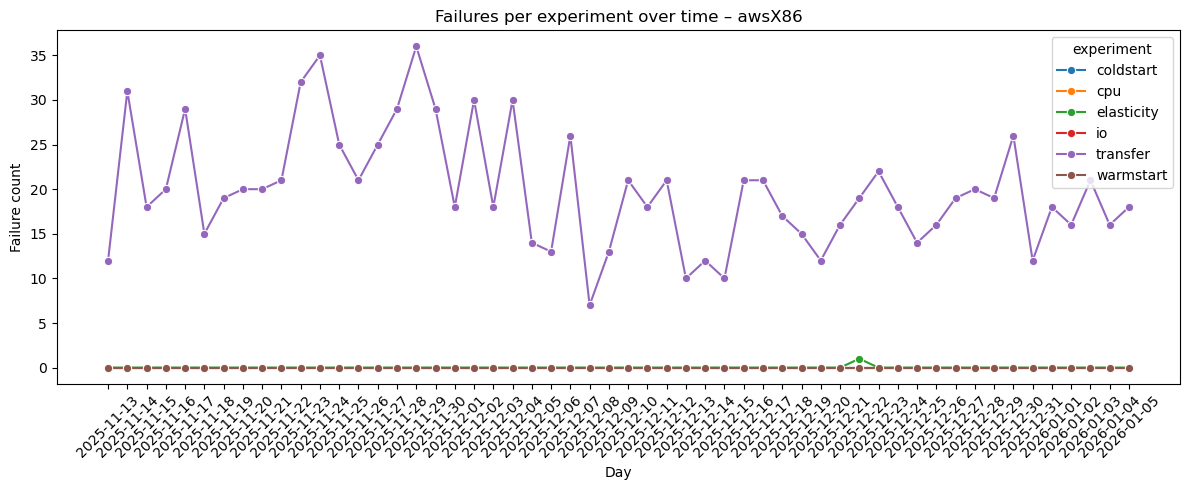

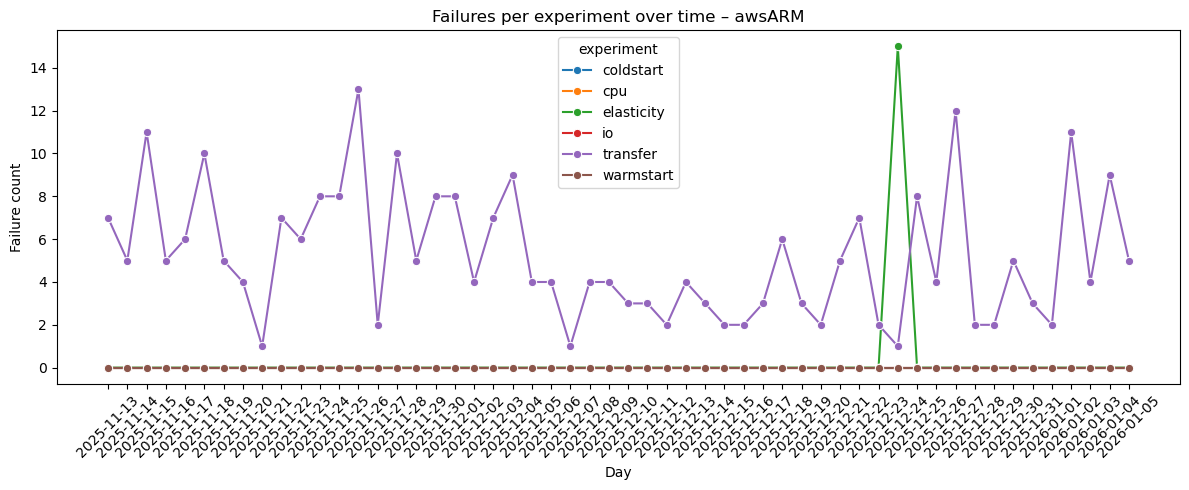

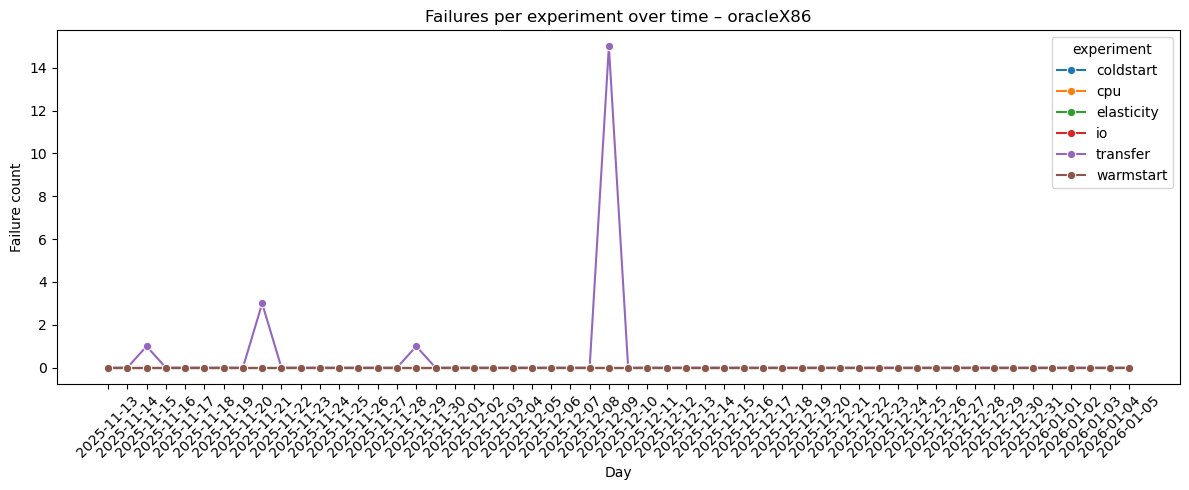

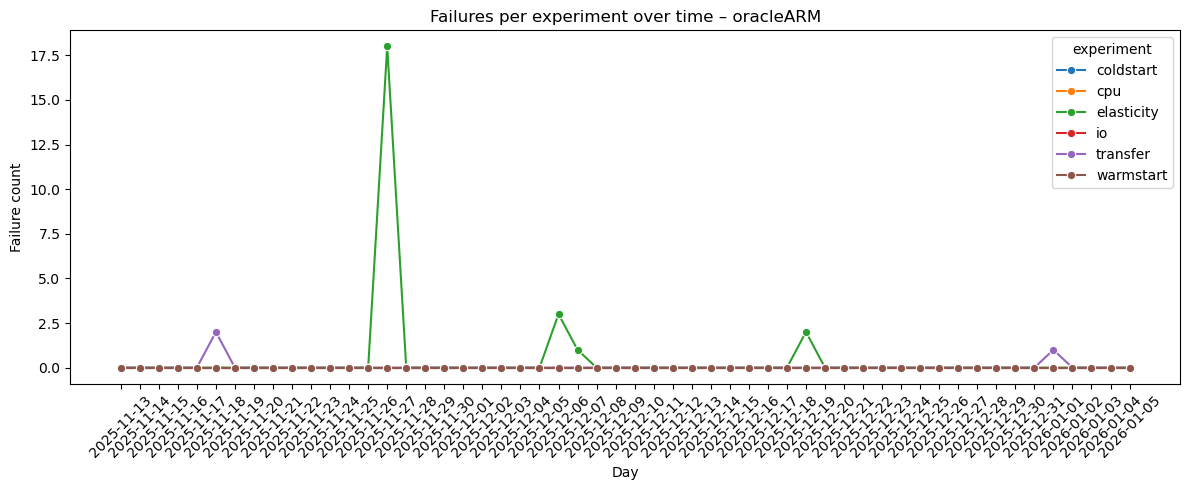

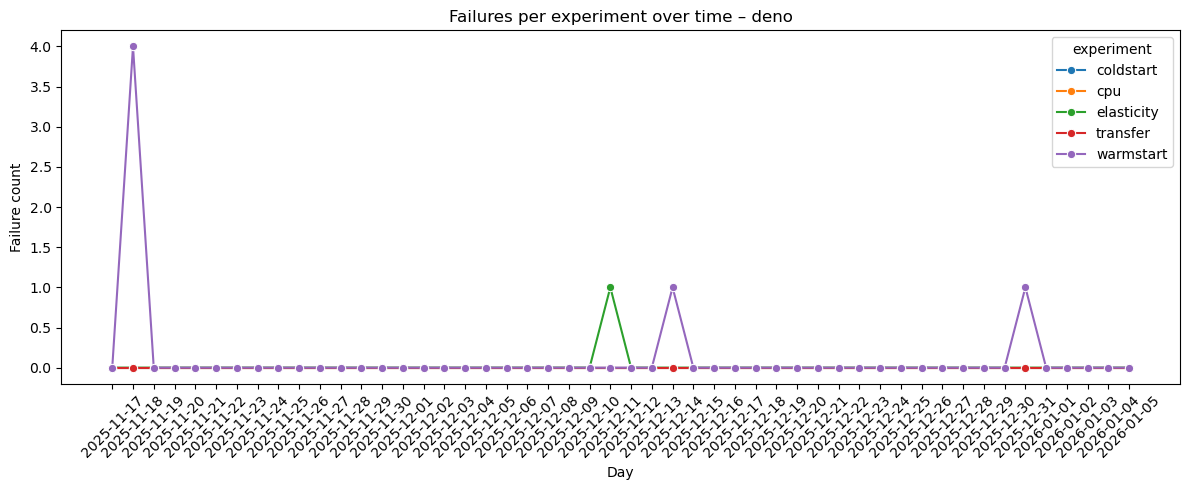

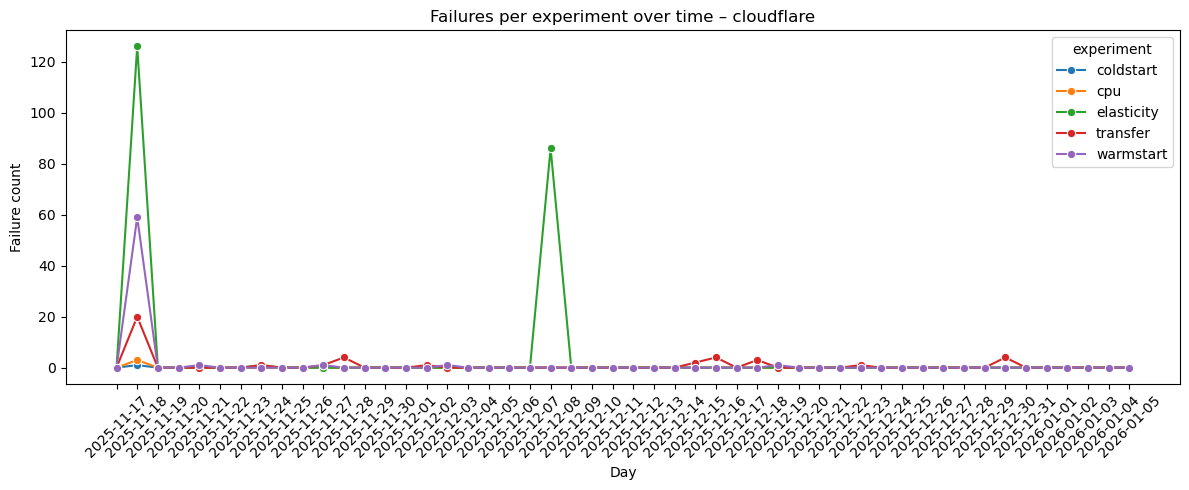

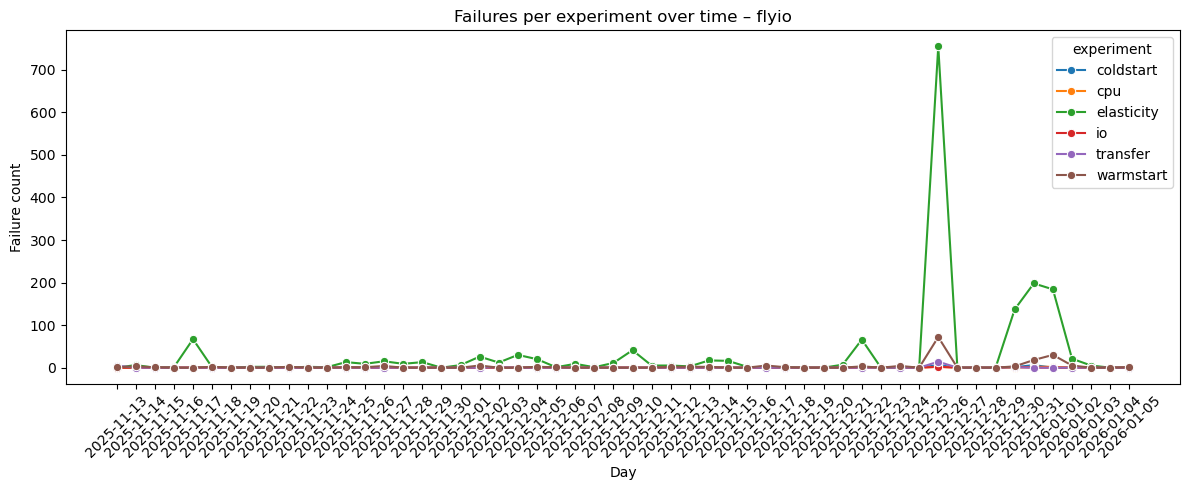

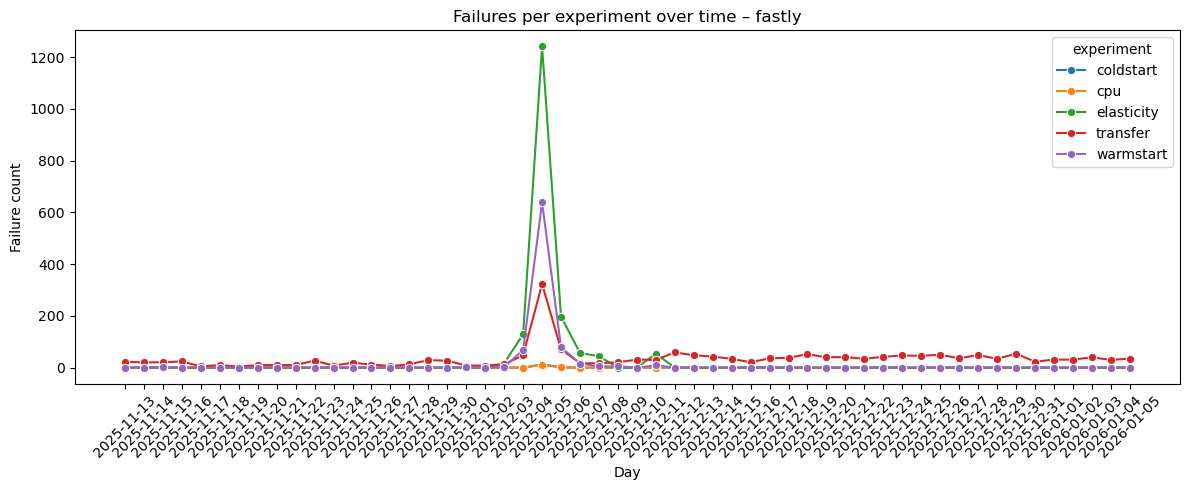

In [9]:
# Look at error occurrences on a global scale (memory efficient)

providers = ["google", "awsX86", "awsARM", "oracleX86", "oracleARM", "deno", "cloudflare", "flyio", "fastly"]

# Aggregate in SQL to avoid loading the full table into memory
query = """
WITH experiment_totals AS (
    SELECT experiment, COUNT(*) AS total_rows
    FROM data
    GROUP BY experiment
),
failures AS (
    SELECT experiment, provider, COUNT(*) AS fail_count
    FROM data
    WHERE errorMessage IS NOT NULL
    GROUP BY experiment, provider
)
SELECT f.experiment, f.provider, f.fail_count, t.total_rows,
       (100.0 * f.fail_count / t.total_rows) AS fail_pct
FROM failures f
JOIN experiment_totals t ON f.experiment = t.experiment
"""

failures = pd.read_sql_query(query, cnx)

# Heatmap: provider vs experiment failure percentage
heatmap_data = (
    failures.pivot(index="provider", columns="experiment", values="fail_pct")
    .reindex(providers)
    .fillna(0)
 )

plt.figure(figsize=(10, 6))
sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".4f",
    cmap="Reds",
    cbar_kws={"label": "Failed requests (% of experiment total)"},
)
plt.title("Failure percentage by provider and experiment")
plt.xlabel("Experiment")
plt.ylabel("Provider")
plt.tight_layout()
plt.show()

# Failures over time per experiment (one chart per provider)
query_time = """
    SELECT
        substr(date_time, 1, 10) AS day,
        provider,
        experiment,
        COUNT(*) AS fail_count
    FROM data
    WHERE errorMessage IS NOT NULL
    GROUP BY day, provider, experiment
"""

failures_time = pd.read_sql_query(query_time, cnx)

# All days where each provider/experiment had any data (to avoid fake flat lines)
days_per_provider_exp = pd.read_sql_query("""
    SELECT DISTINCT
        substr(date_time, 1, 10) AS day,
        provider,
        experiment
    FROM data
""", cnx)

# Ensure experiments/days are shown only when there is data; fill missing failures with 0
failures_time = (
    days_per_provider_exp
    .merge(failures_time, on=["day", "provider", "experiment"], how="left")
    .fillna({"fail_count": 0})
)

for provider in providers:
    df_p = failures_time[failures_time["provider"] == provider]
    if df_p.empty:
        continue

    plt.figure(figsize=(12, 5))
    sns.lineplot(
        data=df_p,
        x="day",
        y="fail_count",
        hue="experiment",
        marker="o"
    )

    plt.title(f"Failures per experiment over time – {provider}")
    plt.xlabel("Day")
    plt.ylabel("Failure count")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

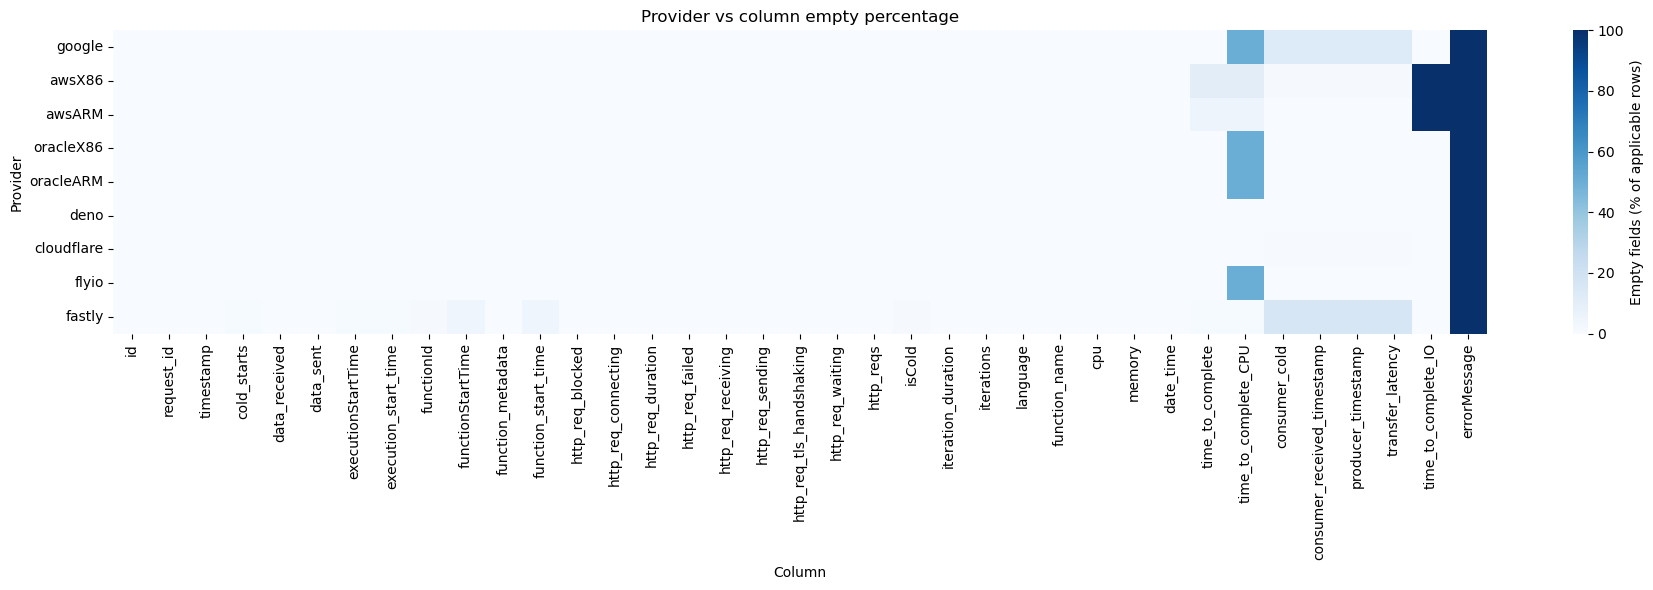

In [13]:
# Empty-field analysis per experiment/provider
import numpy as np

# Discover columns in data table
cols = pd.read_sql_query("PRAGMA table_info(data)", cnx)["name"].tolist()
analysis_cols = [c for c in cols if c not in ("experiment", "provider")]

def _col(c: str) -> str:
    return f'"{c}"'

# Per-experiment non-empty counts to detect applicable columns
nonempty_exprs = [
    f"SUM(CASE WHEN {_col(c)} IS NOT NULL AND {_col(c)} <> '' THEN 1 ELSE 0 END) AS nonempty__{c}"
    for c in analysis_cols
 ]
query_exp = "SELECT experiment, COUNT(*) AS total_rows, " + ", ".join(nonempty_exprs) + " FROM data GROUP BY experiment"
df_nonempty = pd.read_sql_query(query_exp, cnx)

# Map experiment -> applicable columns (not always empty)
applicable_cols = {}
for _, row in df_nonempty.iterrows():
    exp = row["experiment"]
    app = [c for c in analysis_cols if row[f"nonempty__{c}"] > 0]
    applicable_cols[exp] = app

# Per experiment/provider empty counts
empty_exprs = [
    f"SUM(CASE WHEN {_col(c)} IS NULL OR {_col(c)} = '' THEN 1 ELSE 0 END) AS empty__{c}"
    for c in analysis_cols
 ]
query_exp_provider = (
    "SELECT experiment, provider, COUNT(*) AS total_rows, "
    + ", ".join(empty_exprs)
    + " FROM data GROUP BY experiment, provider"
)
df_empty = pd.read_sql_query(query_exp_provider, cnx)

# Provider-column empty percentages (excluding columns always empty for each experiment)
provider_col_stats = {p: {c: [0, 0] for c in analysis_cols} for p in providers}

for _, row in df_empty.iterrows():
    exp = row["experiment"]
    provider = row["provider"]
    total_rows = row["total_rows"]
    app = applicable_cols.get(exp, [])
    if not app or total_rows == 0:
        continue
    for c in app:
        provider_col_stats[provider][c][0] += row[f"empty__{c}"]
        provider_col_stats[provider][c][1] += total_rows

provider_col_pct = pd.DataFrame(index=providers, columns=analysis_cols, dtype=float)
for provider in providers:
    for c in analysis_cols:
        empty_sum, total_sum = provider_col_stats[provider][c]
        provider_col_pct.loc[provider, c] = (100.0 * empty_sum / total_sum) if total_sum else 0.0

# Heatmap: provider vs column empty percentage
plt.figure(figsize=(max(10, len(analysis_cols) * 0.5), 6))
sns.heatmap(
    provider_col_pct.fillna(0),
    annot=False,
    cmap="Blues",
    cbar_kws={"label": "Empty fields (% of applicable rows)"},
)
plt.title("Provider vs column empty percentage")
plt.xlabel("Column")
plt.ylabel("Provider")
plt.tight_layout()
plt.show()